In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("LHCb")

df = pd.read_csv("D:/b_meson_analysis/charm_baryon_analysis/data/lc_candidates.csv")

# Apply same selection
df = df[
    (df["p_PROBNNp"] > 0.5) &
    (df["K_PROBNNk"] > 0.3) &
    (df["pi_PROBNNpi"] > 0.3) &
    (df["Lc_ENDVERTEX_CHI2"] < 5)
]

# Separate signal and background
df_sig = df[df["label"] == 1]
df_bkg = df[df["label"] == 0]

# Dalitz Plot Analysis (Λc+ → pK−π+)

A Dalitz plot represents the distribution of squared invariant masses
of two particle pairs in a three-body decay.

For Λc+ → pK−π+:
- x-axis: m²(pK−)
- y-axis: m²(K−π+)

## Physics meaning

- Uniform distribution → pure phase space
- Bands → intermediate resonances

Examples:
- K*(892) → band in m²(Kπ)
- Δ++(1232) → band in m²(pπ)

Dalitz plots are used to:
- Identify intermediate resonances
- Measure decay amplitudes
- Extract branching fractions

(See Belle: arXiv:1312.7826)

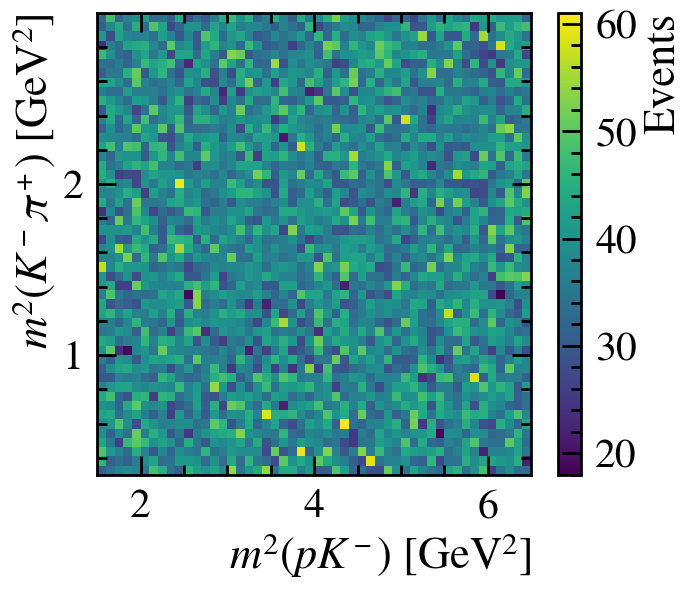

In [2]:
plt.figure(figsize=(7,6))

plt.hist2d(
    df_sig["m2_pK"] / 1e6,
    df_sig["m2_Kpi"] / 1e6,
    bins=50,
    cmap="viridis"
)

plt.xlabel(r"$m^2(pK^-)$ [GeV$^2$]")
plt.ylabel(r"$m^2(K^-\pi^+)$ [GeV$^2$]")

plt.colorbar(label="Events")

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/dalitz_signal.png")
plt.show()

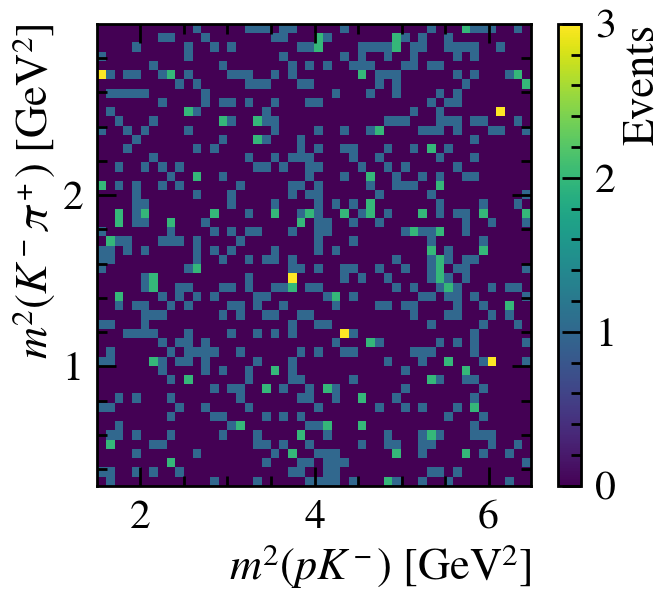

In [3]:
# Define sidebands
df_sideband = df[
    (df["Lc_M"] < 2250) | (df["Lc_M"] > 2320)
]

plt.figure(figsize=(7,6))

plt.hist2d(
    df_sideband["m2_pK"] / 1e6,
    df_sideband["m2_Kpi"] / 1e6,
    bins=50,
    cmap="viridis"
)

plt.xlabel(r"$m^2(pK^-)$ [GeV$^2$]")
plt.ylabel(r"$m^2(K^-\pi^+)$ [GeV$^2$]")

plt.colorbar(label="Events")

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/dalitz_sideband.png")
plt.show()

In [4]:
def compute_dalitz_boundary(M, m1, m2, m3, n_points=500):
    m2_12_vals = np.linspace((m1+m2)**2, (M-m3)**2, n_points)
    m2_23_max = []
    m2_23_min = []

    for m2_12 in m2_12_vals:
        E2 = (m2_12 - m1**2 + m2**2) / (2*np.sqrt(m2_12))
        E3 = (M**2 - m2_12 - m3**2) / (2*np.sqrt(m2_12))

        p2 = np.sqrt(max(E2**2 - m2**2, 0))
        p3 = np.sqrt(max(E3**2 - m3**2, 0))

        m2_23_max.append((E2 + E3)**2 - (p2 - p3)**2)
        m2_23_min.append((E2 + E3)**2 - (p2 + p3)**2)

    return m2_12_vals, np.array(m2_23_min), np.array(m2_23_max)

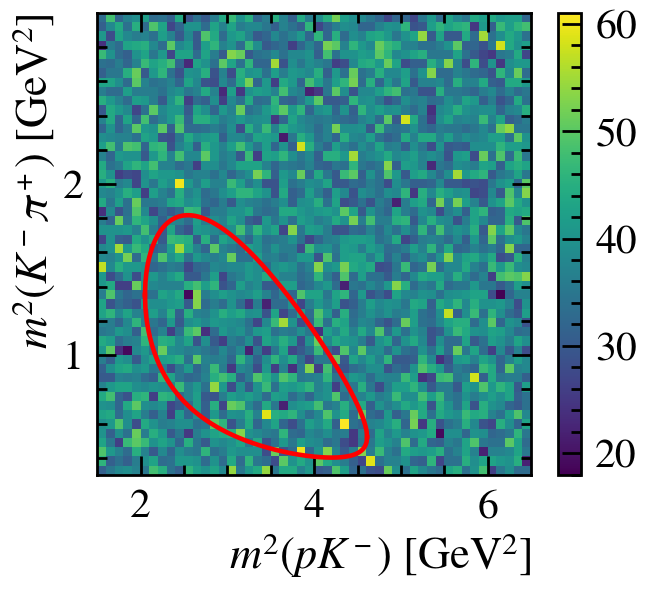

In [5]:
M = 2286.5
mp, mK, mpi = 938.3, 493.7, 139.6

m2_12, m2_23_min, m2_23_max = compute_dalitz_boundary(M, mp, mK, mpi)

plt.figure(figsize=(7,6))

plt.hist2d(
    df_sig["m2_pK"] / 1e6,
    df_sig["m2_Kpi"] / 1e6,
    bins=50,
    cmap="viridis"
)

plt.plot(m2_12/1e6, m2_23_min/1e6, color="red")
plt.plot(m2_12/1e6, m2_23_max/1e6, color="red")

plt.xlabel(r"$m^2(pK^-)$ [GeV$^2$]")
plt.ylabel(r"$m^2(K^-\pi^+)$ [GeV$^2$]")

plt.colorbar()

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/dalitz_boundary.png")
plt.show()

In [14]:
import json

with open("D:/b_meson_analysis/charm_baryon_analysis/results/fit_results.json", "r") as f:
    params = json.load(f)

print("Loaded fit parameters:")
print(params)

Loaded fit parameters:
{'N_sig': 2798.334891941642, 'N_bkg': 17256.169277810157, 'mu': 2287.121626726668, 'sigma': 3.3918527703992547, 'alpha': 1.066625715110758, 'n': 3.853766978439608, 'c1': -2.096256733799861, 'c2': -0.42935466827212065}


In [16]:
# =========================
# CELL 7 — sWeights
# =========================

import numpy as np
import json

# -------------------------
# Load fit parameters
# -------------------------
with open("../results/fit_results.json", "r") as f:
    params = json.load(f)

print("Loaded fit parameters:")
print(params)


# -------------------------
# PDF DEFINITIONS
# -------------------------
def crystalball(x, mu, sigma, alpha, n):
    x = np.array(x)
    t = (x - mu) / sigma

    A = (n / abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)

    result = np.where(
        t > -alpha,
        np.exp(-0.5 * t**2),
        A * (B - t)**(-n)
    )

    return result


def chebychev(x, c1, c2):
    x_scaled = 2 * (x - 2150) / (2450 - 2150) - 1
    T1 = x_scaled
    T2 = 2 * x_scaled**2 - 1
    return 1 + c1 * T1 + c2 * T2


def normalize_pdf(pdf_vals, x):
    area = np.trapezoid(pdf_vals, x)
    return pdf_vals / (area + 1e-10)


# -------------------------
# sWeight computation
# -------------------------
def compute_sweights(df, params):
    x = df["Lc_M"].values

    sig = crystalball(x, params["mu"], params["sigma"],
                      params["alpha"], params["n"])
    bkg = chebychev(x, params["c1"], params["c2"])

    sig = normalize_pdf(sig, x)
    bkg = normalize_pdf(bkg, x)

    denom = params["N_sig"] * sig + params["N_bkg"] * bkg + 1e-10

    w_sig = params["N_sig"] * sig / denom

    return w_sig


# -------------------------
# Apply sWeights
# -------------------------
df["sweight"] = compute_sweights(df, params)

print("sWeights successfully computed!")

Loaded fit parameters:
{'N_sig': 2798.334891941642, 'N_bkg': 17256.169277810157, 'mu': 2287.121626726668, 'sigma': 3.3918527703992547, 'alpha': 1.066625715110758, 'n': 3.853766978439608, 'c1': -2.096256733799861, 'c2': -0.42935466827212065}
sWeights successfully computed!


C:\Users\pc\AppData\Local\Temp\ipykernel_8296\2255409156.py:31: RuntimeWarning: invalid value encountered in power
  A * (B - t)**(-n)


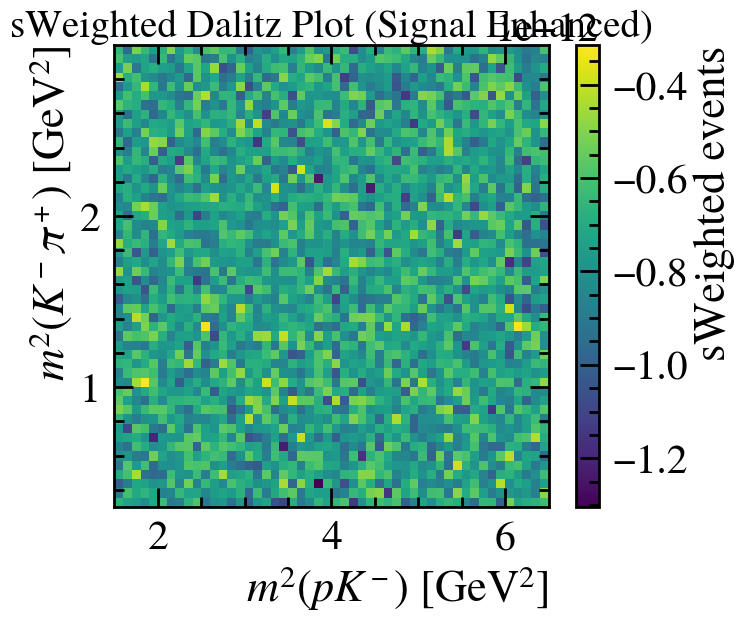

In [17]:
# =========================
# CELL 8 — sWeighted Dalitz Plot
# =========================

plt.figure(figsize=(7,6))

plt.hist2d(
    df["m2_pK"] / 1e6,
    df["m2_Kpi"] / 1e6,
    weights=df["sweight"],
    bins=50,
    cmap="viridis"
)

plt.xlabel(r"$m^2(pK^-)$ [GeV$^2$]")
plt.ylabel(r"$m^2(K^-\pi^+)$ [GeV$^2$]")

plt.colorbar(label="sWeighted events")

plt.title("sWeighted Dalitz Plot (Signal Enhanced)")

plt.savefig("D:/b_meson_analysis/charm_baryon_analysis/plots/dalitz_sweighted.png")
plt.show()

# Dalitz Plot with sWeights — Interpretation

The sWeighted Dalitz plot represents the signal-only distribution after 
statistical subtraction of background using the invariant mass fit.

## Key observations:

- The raw Dalitz plot includes both signal and combinatorial background.
- The sideband plot is mostly flat → confirms background has no structure.
- The sWeighted Dalitz enhances signal structures and suppresses background.

## Physical meaning:

Each event is assigned a weight:

w_sig = N_sig * f_sig(x) / (N_sig f_sig + N_bkg f_bkg)

This allows extraction of signal distributions without explicitly removing events.

## Why this is important:

- Standard technique in Belle II and LHCb
- Avoids bias from hard cuts or sideband subtraction
- Preserves full statistical power

## Reference:

M. Pivk & F.R. Le Diberder  
Nucl. Instrum. Meth. A555 (2005) 356